In [1]:
import os 
import numpy as np 
import matplotlib.pyplot as plt 
from pathlib import Path
import math
import flopy 
import flopy.utils.binaryfile as bf
import flopy.discretization as fgrid
from flopy.utils.gridintersect import GridIntersect
from shapely.geometry import MultiLineString
from osgeo import gdal, ogr

In [2]:
import geopandas as gpd

In [3]:
basinDf = gpd.read_file(r'data_folder_versoix_sector\BV_versoix.shp') 
riverDf = gpd.read_file(r'data_folder_versoix_sector\BV_river_comp.shp')
catchDf = gpd.read_file(r'data_folder_versoix_sector\BV_catch.shp')
lakeDf = gpd.read_file(r'data_folder_versoix_sector\lake_BC.shp')

Axes(0.125,0.11;0.775x0.77) Figure(500x500)


<Axes: >

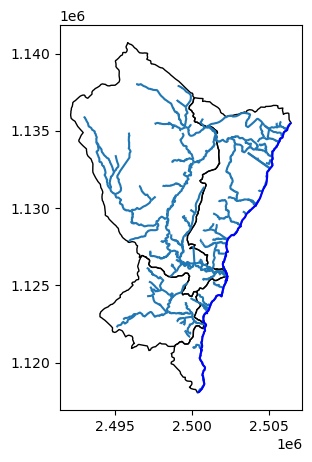

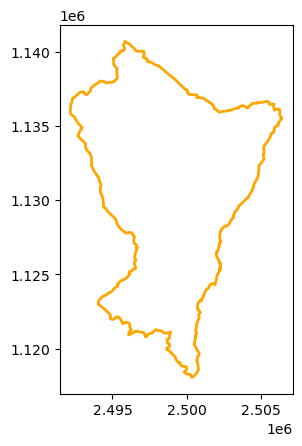

In [4]:
fig, ax = plt.subplots(figsize=(5,5))
print(ax,fig)
riverDf.plot(ax=ax, facecolor='none')
lakeDf.plot(ax=ax, facecolor='none', edgecolor='b')
catchDf.plot(ax=ax, facecolor='none')
basinDf.plot(facecolor='none', edgecolor='orange', lw=2, ls='-')

In [5]:
basinGeom = basinDf.iloc[0].geometry

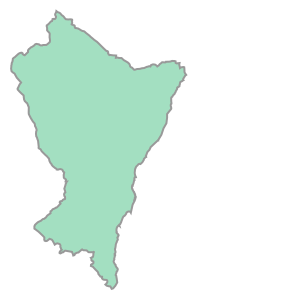

In [6]:
basinGeom

In [7]:
basinGeomXDim = basinGeom.bounds[2] - basinGeom.bounds[0]
basinGeomYDim = basinGeom.bounds[3] - basinGeom.bounds[1]

In [8]:
basinGeom.bounds[0], basinGeom.bounds[1], basinGeom.bounds[2], basinGeom.bounds[3]

(2492149.9217999987,
 1118059.4734999985,
 2506429.2743000016,
 1140714.6670999974)

In [9]:
from pyexpat import model


model_ws = 'Results_BV'
modelname = 'Versoix_BV'
exe_name = '../Exe/mf6.exe'

sim = flopy.mf6.MFSimulation(sim_name=modelname, exe_name=exe_name, sim_ws = model_ws)

In [10]:
perioddata = [(1., 1, 1.)]
nper = len(perioddata)
tdis = flopy.mf6.ModflowTdis(sim, nper=nper, perioddata=perioddata,
time_units='seconds')

In [11]:
ims = flopy.mf6.ModflowIms(sim,linear_acceleration='BICGSTAB ')

In [12]:
gwf = flopy.mf6.ModflowGwf(sim, modelname=modelname, save_flows=True,
newtonoptions=['under_relaxation'])

In [13]:
ztop = 100
zbot = 0
nlay = 1
delr = 200
delc = 200
nrow = math.ceil(basinGeomYDim/delc)
ncol = math.ceil(basinGeomXDim/delr)

In [14]:
nrow,ncol

(114, 72)

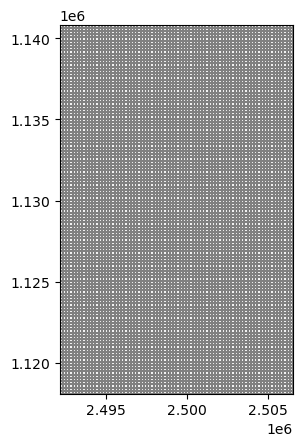

In [15]:
sgr = fgrid.StructuredGrid(delc*np.ones(nrow), delr*np.ones(ncol),
xoff=basinGeom.bounds[0], yoff=basinGeom.bounds[1])
sgr.plot()

In [16]:
ix = GridIntersect(sgr, method="vertex", rtree=True)

In [17]:
basin_intersected = ix.intersect(basinGeom)

In [18]:
basin_intersected.dtype.descr

[('cellids', '|O'), ('ixshapes', '|O'), ('areas', '<f8')]

In [19]:
idomain = np.zeros((nlay,nrow,ncol))
for i in basin_intersected.cellids:
    idomain[:,i[0],i[1]] = 1

In [20]:
dis = flopy.mf6.ModflowGwfdis(gwf, nlay=nlay, nrow=nrow, ncol=ncol, delr=delr,delc=delc, top=ztop, botm=zbot, idomain=idomain)
gwf.modelgrid.set_coord_info(xoff=basinGeom.bounds[0], yoff=basinGeom.bounds[1], angrot=0,crs=2056)

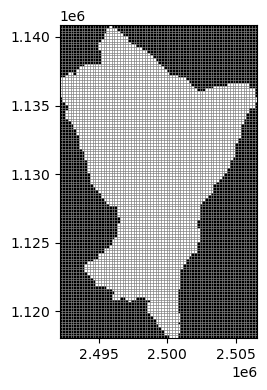

In [21]:
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(1, 1, 1, aspect='equal')
modelmap = flopy.plot.PlotMapView(model=gwf, ax=ax)
actives = modelmap.plot_ibound()
linecollection = modelmap.plot_grid(linewidth=0.5)

fig.tight_layout()

In [22]:
# Get Elevation  data 
# Converted raster to xyz in qgis using gdal
# https://gis.stackexchange.com/questions/217890/converting-tif-to-xyz-in-qgis

import pandas as pd
from scipy.interpolate import griddata

dem = pd.read_csv(r'data_folder_versoix_sector/MNT_BV_pos.csv',sep=';')
print(dem.head())

       Easting     Northing  Elevation
0  2495849.319  1140699.112     1441.9
1  2495849.319  1140674.112     1440.6
2  2495874.319  1140674.112     1435.0
3  2495849.319  1140649.112     1440.4
4  2495874.319  1140649.112     1431.5


In [23]:
points = dem[['Easting', 'Northing']].values
values = dem['Elevation'].values
grid_x = gwf.modelgrid.xcellcenters
grid_y = gwf.modelgrid.ycellcenters 
mtop = griddata(points, values, (grid_x, grid_y), method='nearest')

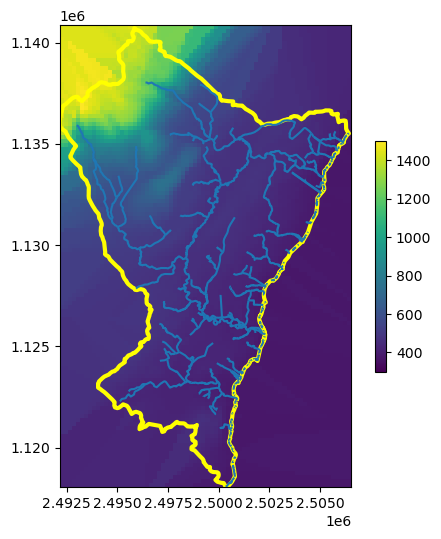

<Figure size 640x480 with 0 Axes>

In [24]:
# lowest elevation = 1308.59
# lowest elevation2 = 1100.0
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1, aspect='equal')
modelmap = flopy.plot.PlotMapView(model=gwf,ax=ax)
quadmesh = modelmap.plot_array(mtop, **{"vmin":300.0})
basinDf.plot(ax=ax, facecolor='none', edgecolor='yellow', lw=3)
riverDf.plot(ax=ax, facecolor='none')
fig.colorbar(quadmesh, ax=ax, shrink=0.5)
plt.show()
plt.clf()

fig.tight_layout()

In [25]:
gwf.dis.top = mtop

In [26]:
zbot = np.zeros((nlay,nrow,ncol))
zbot[0,:,:] = mtop - (1510 - mtop)*0.1

In [27]:
(1510 - np.min(mtop))*0.1, (1510 - np.max(mtop))*0.1

(113.60000000000001, 0.709999999999991)

In [28]:
np.min(mtop), np.max(mtop)

(374.0, 1502.9)

In [29]:
lst_active_cells = []
for irow in range(nrow):
    for icol in range(ncol):
        if idomain[0, irow, icol] == 1:
            lst_active_cells.append((0, irow, icol))

In [30]:
gwf.dis.botm = zbot

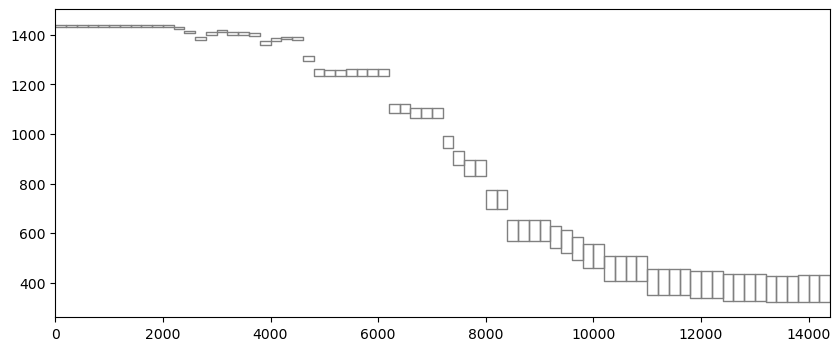

In [31]:
fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(1, 1, 1)
modelxsect = flopy.plot.PlotCrossSection(model=gwf, line={'Row': 2})
linecollection = modelxsect.plot_grid()

In [32]:
ic = flopy.mf6.ModflowGwfic(gwf, strt=np.stack([mtop for i in
range(nlay)]))

In [33]:
Kx = np.zeros((nlay,nrow,ncol))
Kx[0,:,:] = 9E-5
icelltype = [1]
npf = flopy.mf6.ModflowGwfnpf(gwf,
save_specific_discharge=True,
icelltype=icelltype,
k=Kx)

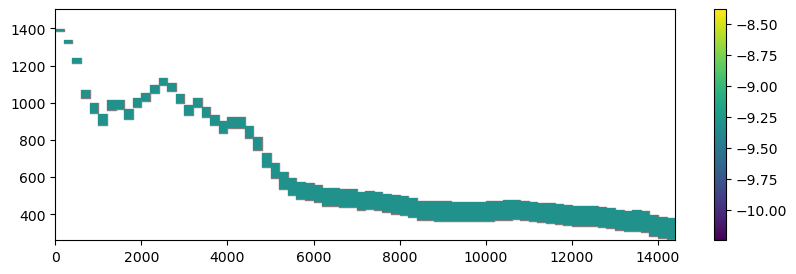

In [34]:
fig = plt.figure(figsize=(10, 3))
ax = fig.add_subplot(1, 1, 1)
modelxsect = flopy.plot.PlotCrossSection(model=gwf, line={'Row': 26})
linecollection = modelxsect.plot_grid()
cb = modelxsect.plot_array(np.log(Kx))
plt.colorbar(cb)

In [35]:
yr_precip = 1 #Data from Meteoswiss
recharge_ratio = 1/3 #Rule of thumb
rchr = yr_precip*recharge_ratio/365/86400 #m/yr -> m/s
rch = flopy.mf6.ModflowGwfrcha(gwf, recharge=rchr)

In [36]:
1/3/365/86400

1.0569930661254863e-08

In [37]:
river_coos = np.array(riverDf.get_coordinates())

In [38]:
riverGeom = riverDf.iloc[0].geometry

In [39]:
river_intersected = ix.intersect(riverGeom)

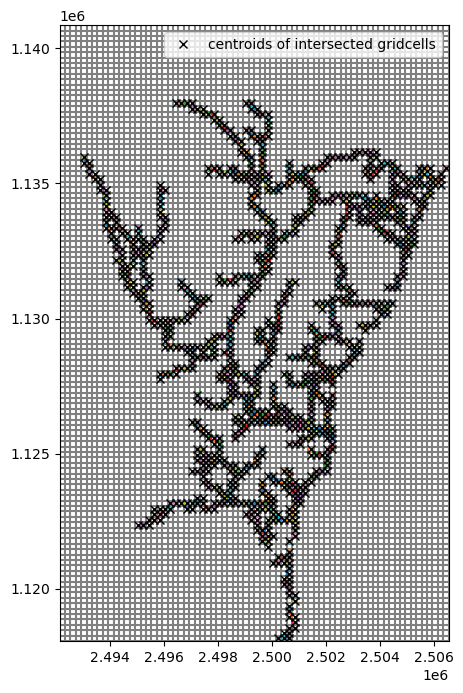

In [40]:
# create a figure and plot the grid
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# the intersection object contains some helpful plotting commands
ix.plot_intersection_result(river_intersected, ax=ax)

# add black x at cell centers
for irow, icol in river_intersected.cellids:
    (h2,) = ax.plot(
        sgr.xcellcenters[0, icol],
        sgr.ycellcenters[irow, 0],
        "kx",
        label="centroids of intersected gridcells",
    )

# add legend
ax.legend([h2], [i.get_label() for i in [h2]], loc="best")
plt.show()

In [41]:
riv_points = []
for n in river_intersected.cellids: #Creating a key to id cells
    for m in n:
        riv_points.append(str(n[0])+'-'+str(n[1])) 

In [42]:
#Add the drain package (DRN) to the MODFLOW model
river = np.zeros(mtop.shape, dtype=np.int32)
riv_list = []
for i in range(river.shape[0]):
    for q in range(river.shape[1]):
        if f'{i}-{q}' in riv_points :
            riv_list.append([0, i, q, mtop[i,q]-1, 0.001, mtop[i,q]-2]) 
rivDrn = {0:riv_list}

riv = flopy.mf6.ModflowGwfriv(gwf, maxbound=len(riv_list), stress_period_data=rivDrn,save_flows=True)

In [43]:
lakeGeom = lakeDf.iloc[0].geometry 

In [44]:
lake_intersected = ix.intersect(lakeGeom)

In [45]:
lake_points = []
for n in lake_intersected.cellids: #Creating a key to id cells
    for m in n:
        lake_points.append(str(n[0])+'-'+str(n[1])) 

In [46]:
lake = np.zeros(mtop.shape, dtype=np.int32)
lake_list = []
for i in range(lake.shape[0]):
    for q in range(lake.shape[1]):
        if f'{i}-{q}' in lake_points :
            if i < nrow and q < ncol:
                lake_list.append([(0, i, q), 372]) #(layer,row,column), constant head
            else:
                print(f"Out of bound : ({i}, {q})")
            
lakDrn = []

for j in lake_list:
    cell = j[0]
    if cell in lst_active_cells:
        lakDrn.append(j)


chdPackage = flopy.mf6.ModflowGwfchd(gwf, maxbound=len(lakDrn),stress_period_data=lakDrn, save_flows=True)

In [47]:
iper = 0
ra = chdPackage.stress_period_data.get_data(key=iper)
ra

rec.array([((0, 26, 71), 372), ((0, 27, 70), 372), ((0, 27, 71), 372),
           ((0, 28, 70), 372), ((0, 29, 68), 372), ((0, 29, 69), 372),
           ((0, 29, 70), 372), ((0, 30, 68), 372), ((0, 31, 67), 372),
           ((0, 31, 68), 372), ((0, 32, 67), 372), ((0, 33, 66), 372),
           ((0, 33, 67), 372), ((0, 34, 66), 372), ((0, 35, 65), 372),
           ((0, 35, 66), 372), ((0, 36, 65), 372), ((0, 37, 65), 372),
           ((0, 38, 65), 372), ((0, 39, 65), 372), ((0, 40, 64), 372),
           ((0, 40, 65), 372), ((0, 41, 64), 372), ((0, 42, 63), 372),
           ((0, 42, 64), 372), ((0, 43, 63), 372), ((0, 44, 63), 372),
           ((0, 45, 63), 372), ((0, 46, 63), 372), ((0, 47, 62), 372),
           ((0, 47, 63), 372), ((0, 48, 62), 372), ((0, 49, 61), 372),
           ((0, 50, 61), 372), ((0, 51, 60), 372), ((0, 51, 61), 372),
           ((0, 52, 60), 372), ((0, 53, 59), 372), ((0, 53, 60), 372),
           ((0, 54, 58), 372), ((0, 54, 59), 372), ((0, 55, 57), 372),
      

In [48]:
hname = '{}.hds'.format(modelname)
cname = '{}.cbc'.format(modelname)
oc = flopy.mf6.ModflowGwfoc(gwf, budget_filerecord=cname,
head_filerecord=hname,
saverecord=[('HEAD', 'ALL'), ('BUDGET','ALL')])

In [50]:
os.chdir(r'test_BV')

In [51]:
sim.write_simulation()
sim.run_simulation()

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model Versoix_BV...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package rcha_0...
    writing package riv_0...
    writing package chd_0...
    writing package oc...
FloPy is using the following executable to run the model: ..\Exe\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.5.0 05/23/2024

   MODFLOW 6 compiled May 23 2024 18:06:57 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.7.0
                             Build 20220726_000000

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the USGS reserves the right

(True, [])

In [52]:
#hds = bf.HeadFile(model_ws+'/'+modelname + '.hds')
model_path = 'C:/Users/Noah/OneDrive - unine.ch/Documents/Unine/Master Thesis/4. Modflow model/example_modelregional/' #Model path
hds = bf.HeadFile(model_path+model_ws+'/'+modelname + '.hds')
head = hds.get_data(totim=1.0)
head[head==1e+30]=np.nan

In [53]:
cpth = os.path.join(model_path+model_ws, modelname+'.cbc')
cobj = flopy.utils.CellBudgetFile(cpth, precision=hds.precision)
spd = cobj.get_data(text='DATA-SPDIS')[0]

<Axes: title={'center': 'Regional Model'}>

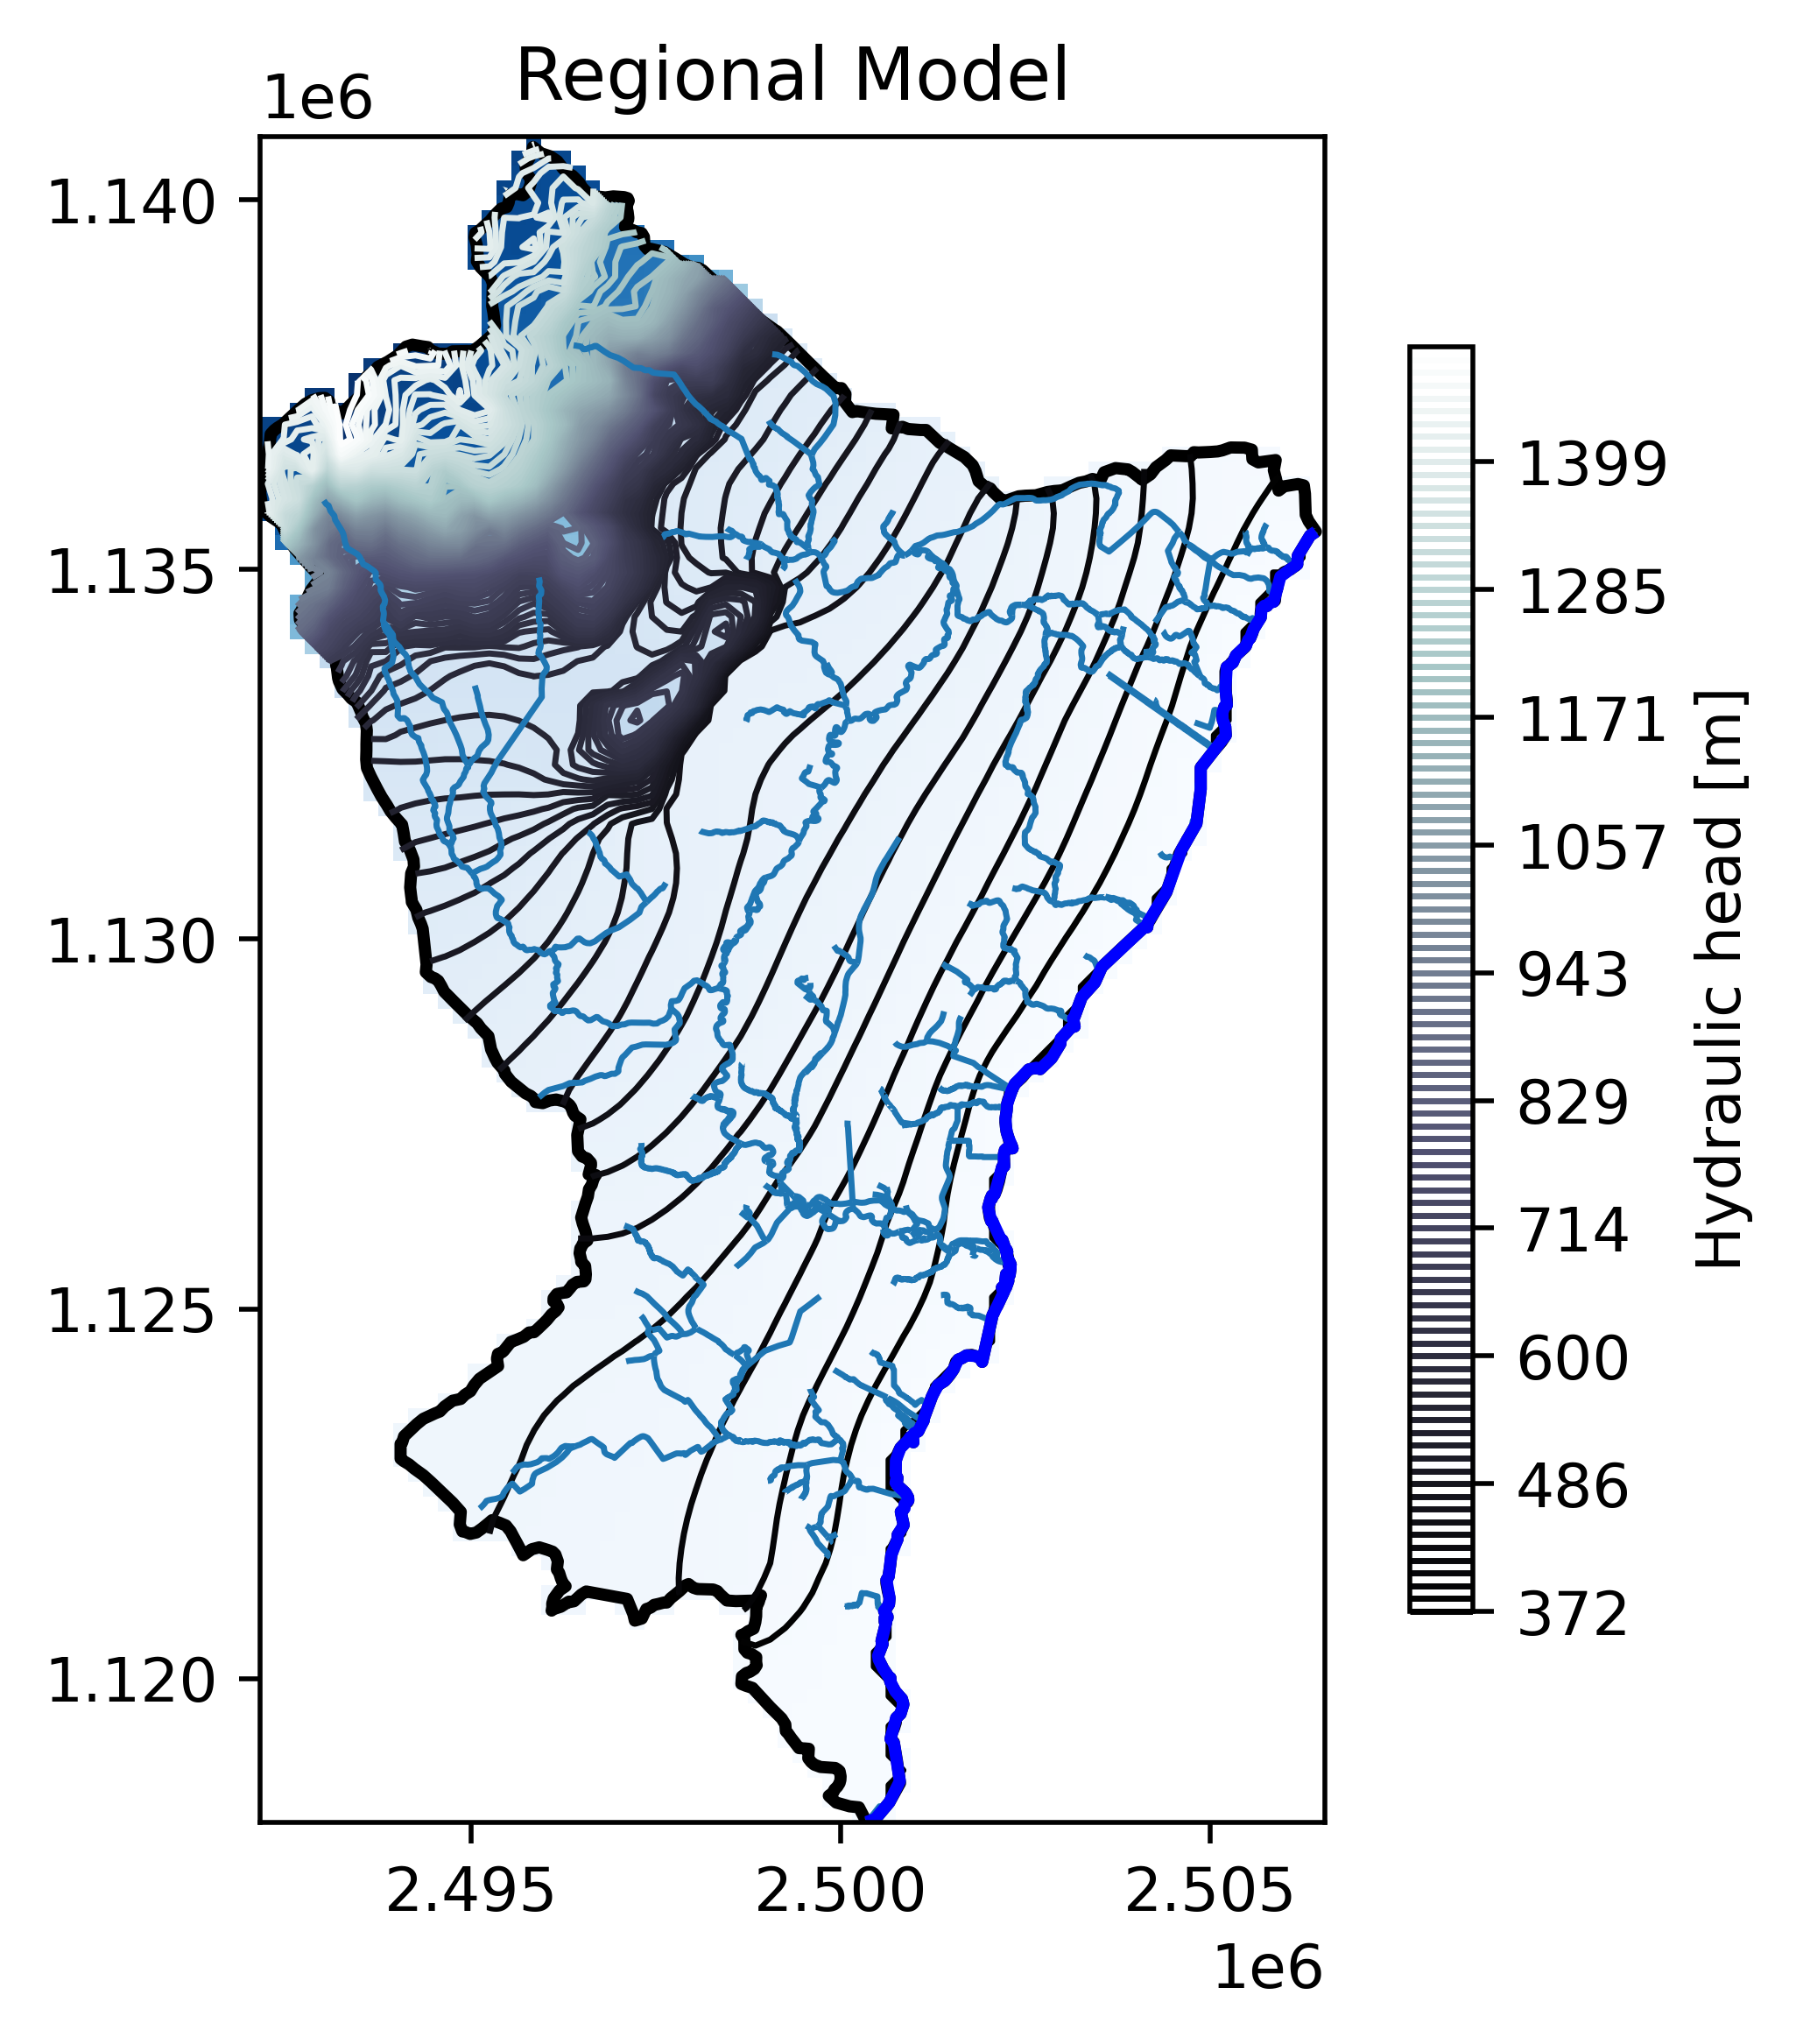

In [55]:
fig = plt.figure(figsize=(5, 5),dpi=500)
ax = fig.add_subplot(1, 1, 1, aspect='equal')
mapview = flopy.plot.PlotMapView(model=gwf)
levels = np.linspace(np.nanmin(head),np.nanmax(head),num=100)
contour_set = mapview.contour_array(head,levels=levels, linewidths=1, cmap='bone')
t = ax.set_title("Regional Model")
plt.colorbar(contour_set, shrink=0.75, label='Hydraulic head [m]')

pc = mapview.plot_array(head, cmap="Blues")

basinDf.plot(ax=ax, facecolor='none', edgecolor='k', lw=2, zorder=1)
riverDf.plot(ax=ax, facecolor='none', alpha=1, lw=1)
lakeDf.plot(ax=ax, facecolor='none', edgecolor='b', lw=2)

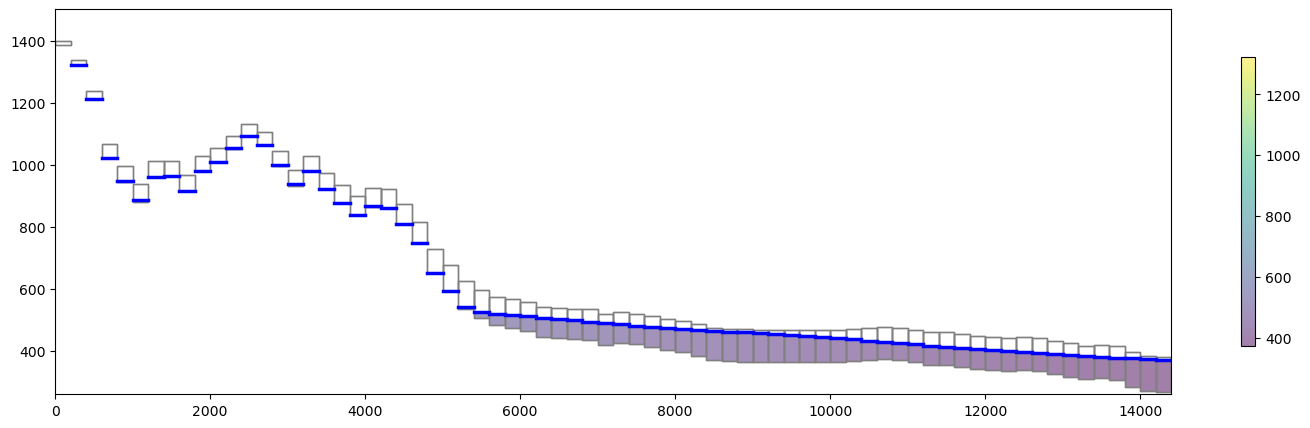

In [58]:
fig = plt.figure(figsize=(18, 5))
ax = fig.add_subplot(1, 1, 1)
xsect = flopy.plot.PlotCrossSection(model=gwf, line={'Row':26})
pc = xsect.plot_array(head, head=head, alpha=0.5)
patches = xsect.plot_ibound(head=head)
linecollection = xsect.plot_grid()
wt = xsect.plot_surface(head[0], masked_values=[999.], color='blue',
lw=2.5)
linecollection = xsect.plot_grid()
cb = plt.colorbar(pc, shrink=0.75)

In [59]:
ix = GridIntersect(sgr, method="vertex", rtree=True)

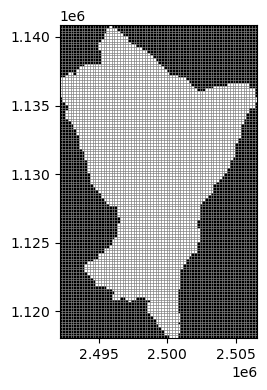

In [60]:
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(1, 1, 1, aspect='equal')
modelmap = flopy.plot.PlotMapView(model=gwf, ax=ax)
actives = modelmap.plot_ibound()
linecollection = modelmap.plot_grid(linewidth=0.5)

fig.tight_layout()

## Zone Budget

In [61]:
# Versoix sector
VersoixDf = gpd.read_file(r'data_folder_versoix_sector/Versoix_riv_sector.shp') 
BC_NorthDf = gpd.read_file(r'data_folder_versoix_sector/BC_North.shp') 
BC_WestDf = gpd.read_file(r'data_folder_versoix_sector/BC_West.shp') 
BC_SouthDf = gpd.read_file(r'data_folder_versoix_sector/South_river_2.shp') 

In [62]:
VersoixGeom = VersoixDf.iloc[0].geometry
Versoix_intersected = ix.intersect(VersoixGeom)

In [63]:
NorthGeom = BC_NorthDf.iloc[0].geometry
North_intersected = ix.intersect(NorthGeom)
WestGeom = BC_WestDf.iloc[0].geometry
West_intersected = ix.intersect(WestGeom)
SouthGeom = BC_SouthDf.iloc[0].geometry
South_intersected = ix.intersect(SouthGeom)

In [64]:
Ver_points = []
for n in Versoix_intersected.cellids: #Creating a key to id cells
    for m in n:
        Ver_points.append(str(n[0])+'-'+str(n[1])) 

In [65]:
North_points = []
for n in North_intersected.cellids: #Creating a key to id cells
    for m in n:
        North_points.append(str(n[0])+'-'+str(n[1])) 

West_points = []
for n in West_intersected.cellids: #Creating a key to id cells
    for m in n:
        West_points.append(str(n[0])+'-'+str(n[1])) 

South_points = []
for n in South_intersected.cellids: #Creating a key to id cells
    for m in n:
        South_points.append(str(n[0])+'-'+str(n[1])) 

In [66]:
North = np.zeros(mtop.shape, dtype=np.int32)

for i in range(North.shape[0]):
    for q in range(North.shape[1]):
        if f'{i}-{q}' in North_points :
            North[i][q] = 1
        elif f'{i}-{q}' in Ver_points :
            North[i][q] = 2

West = np.zeros(mtop.shape, dtype=np.int32)

for i in range(West.shape[0]):
    for q in range(West.shape[1]):
        if f'{i}-{q}' in West_points :
            West[i][q] = 1
        elif f'{i}-{q}' in Ver_points :
            West[i][q] = 2

South = np.zeros(mtop.shape, dtype=np.int32)

for i in range(South.shape[0]):
    for q in range(South.shape[1]):
        if f'{i}-{q}' in South_points :
            South[i][q] = 1
        elif f'{i}-{q}' in Ver_points :
            South[i][q] = 2

In [67]:
ml = sim.get_model(modelname)

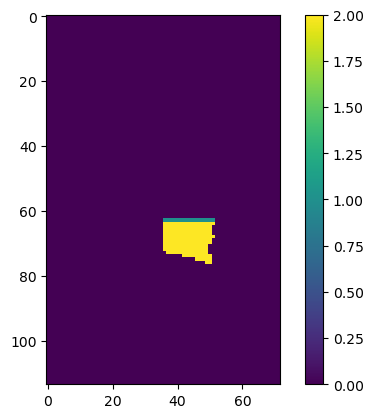

In [68]:
plt.imshow(North)
plt.colorbar()

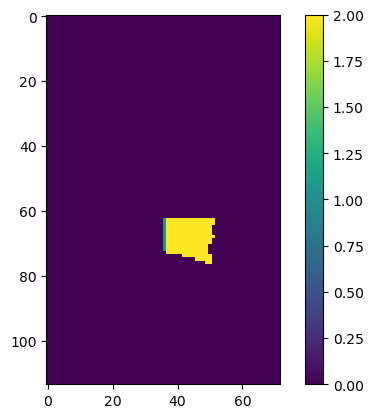

In [69]:
plt.imshow(West)
plt.colorbar()

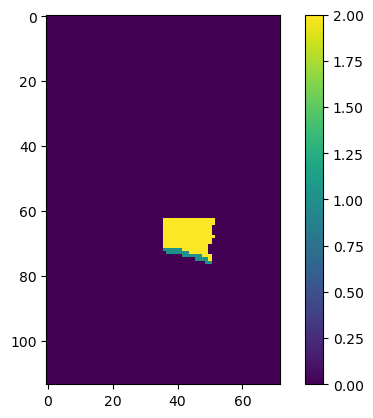

In [70]:
plt.imshow(South)
plt.colorbar()

In [71]:
workspace = Path(model_path)
cpthn = workspace / "zbud6_BV_N"
#cpthn.mkdir()

In [72]:
zb6_exe = "../zbud6_BV_N/zbud6.exe"
zonbudn = ml.output.zonebudget(North)
zonbudn.change_model_ws(cpthn)
zonbudn.write_input()
successn, buffn = zonbudn.run_model(exe_name=zb6_exe, silent=True)

In [73]:
workspace = Path(model_path)
cpthw = workspace / "zbud6_BV_W"
#cpthw.mkdir()

In [74]:
zb6_exe = "../zbud6_BV_W/zbud6.exe"
zonbudw = ml.output.zonebudget(West)
zonbudw.change_model_ws(cpthw)
zonbudw.write_input()
successw, buffw = zonbudw.run_model(exe_name=zb6_exe, silent=True)

In [75]:
workspace = Path(model_path)
cpths = workspace / "zbud6_BV_S"
#cpths.mkdir()

In [76]:
zb6_exe = "../zbud6_BV_S/zbud6.exe"
zonbuds = ml.output.zonebudget(South)
zonbuds.change_model_ws(cpths)
zonbuds.write_input()
successs, buffs = zonbuds.run_model(exe_name=zb6_exe, silent=True)

In [77]:
zonbuds.get_budget()

rec.array([(1., 0, 0, 'DATA_SPDIS_IN', 0.        , 0.        ),
           (1., 0, 0, 'RIV_IN', 0.015     , 0.059     ),
           (1., 0, 0, 'RCHA_IN', 0.01014713, 0.05834602),
           (1., 0, 0, 'CHD_IN', 0.        , 0.        ),
           (1., 0, 0, 'DATA_SPDIS_OUT', 0.        , 0.        ),
           (1., 0, 0, 'RIV_OUT', 0.02988545, 0.00107955),
           (1., 0, 0, 'RCHA_OUT', 0.        , 0.        ),
           (1., 0, 0, 'CHD_OUT', 0.01436967, 0.53657819),
           (1., 0, 0, 'FROM_ZONE_0', 0.10810996, 0.42685517),
           (1., 0, 0, 'FROM_ZONE_1', 0.        , 0.11520302),
           (1., 0, 0, 'FROM_ZONE_2', 0.12174722, 0.        ),
           (1., 0, 0, 'TO_ZONE_0', 0.09554632, 0.        ),
           (1., 0, 0, 'TO_ZONE_1', 0.        , 0.12174722),
           (1., 0, 0, 'TO_ZONE_2', 0.11520302, 0.        )],
          dtype=[('totim', '<f8'), ('time_step', '<i4'), ('stress_period', '<i4'), ('name', 'O'), ('ZONE_1', '<f8'), ('ZONE_2', '<f8')])

In [86]:
zonbudn.get_budget()

rec.array([(1., 0, 0, 'DATA_SPDIS_IN', 0.        , 0.        ),
           (1., 0, 0, 'RIV_IN', 0.005     , 0.069     ),
           (1., 0, 0, 'RCHA_IN', 0.00634196, 0.06215119),
           (1., 0, 0, 'CHD_IN', 0.        , 0.        ),
           (1., 0, 0, 'DATA_SPDIS_OUT', 0.        , 0.        ),
           (1., 0, 0, 'RIV_OUT', 0.        , 0.030965  ),
           (1., 0, 0, 'RCHA_OUT', 0.        , 0.        ),
           (1., 0, 0, 'CHD_OUT', 0.05906956, 0.4918783 ),
           (1., 0, 0, 'FROM_ZONE_0', 0.25637495, 0.27859017),
           (1., 0, 0, 'FROM_ZONE_1', 0.        , 0.20864744),
           (1., 0, 0, 'FROM_ZONE_2', 0.        , 0.        ),
           (1., 0, 0, 'TO_ZONE_0', 0.        , 0.09554632),
           (1., 0, 0, 'TO_ZONE_1', 0.        , 0.        ),
           (1., 0, 0, 'TO_ZONE_2', 0.20864744, 0.        )],
          dtype=[('totim', '<f8'), ('time_step', '<i4'), ('stress_period', '<i4'), ('name', 'O'), ('ZONE_1', '<f8'), ('ZONE_2', '<f8')])

In [ ]:
zonbudw.get_budget()